<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/13-BERT_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>BERT</h1>

En esta notebook exploraremos el uso de modelos tipo BERT para resolver la tarea de *Análisis de Sentimientos*. Esto lo haremos de dos formas:

1. Haciendo fine-tuning a un modelo BERT.
2. Usando los embeddings generados por BERT como features para un algoritmo de ML.

Usaremos modelos pre-entrenados almacenados en [HuggingFace](https://huggingface.co/).

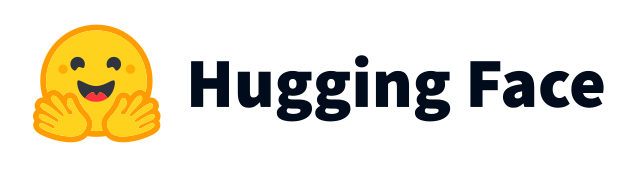

---

*Hugging Face, Inc. es una empresa estadounidense conocida por su biblioteca de transformadores creada para aplicaciones de procesamiento de lenguaje natural y su plataforma que permite a los usuarios compartir [datasets](https://huggingface.co/datasets) y [modelos](https://huggingface.co/models) de aprendizaje automático.  Su campo de acción principal es el NLP, pero también se centra en otras áreas del ML, como la visión de máquina, el aprendizaje por refuerzo y el aprendizaje supervisado.*

---

Regresaremos al dataset de 50K reviews de [IMDB](https://www.imdb.com/). Recordemos los rendimientos que habíamos obtenido:

* **Naive Bayes y ML clásico**. Accuracy: $\sim$ 75-82%.
* **Embeddings de Word2Vec, GloVe, Doc2Vec**. Accuracy: $\sim$ 85-87%.
* **BERT**: Accuracy $\sim$ ❓

# 1. Dataset

In [ ]:
!gdown 1957iWcYLqlL2eVWAYgzyJWNIyBf6GEYD

Leemos el dataset y hacemos la división en

* Entrenamiento: 8,000
* Validación: 1,000
* Prueba: 1,000

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

imdb_df = pd.read_csv('10K_movie_reviews.csv')
display(imdb_df)

y = LabelEncoder().fit_transform(imdb_df['label'].values)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(imdb_df['text'].values, y, test_size=0.2, random_state=642, stratify=y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw, y_train, test_size=0.25, random_state=473, stratify=y_train)
print(f"Training set size: {len(X_train_raw)}")
print(f"Validation set size: {len(X_val_raw)}")
print(f"Test set size: {len(X_test_raw)}")

In [ ]:
import numpy as np

random_idxs = np.random.choice(len(X_train_raw), size=4, replace=False)

for k in random_idxs:
    print(f"Review:\n{X_train_raw[k]}")

#2. Limpieza y preprocesamiento

En los modelos de lenguaje modernos como BERT y sus sucesores, el preprocesamiento tradicional del texto (como la eliminación de stopwords, lematización o stemming) ya no es necesario ni recomendable.

Estos modelos están diseñados para entender el contexto y la estructura del lenguaje tal como aparece en el texto crudo, incluyendo palabras funcionales que aportan significado contextual.

Sin embargo, sí es común limpiar el texto de artefactos no lingüísticos, como etiquetas HTML, códigos de escape, URLs, o caracteres especiales irrelevantes.

En su lugar, el preprocesamiento se limita generalmente a la tokenización mediante el tokenizador específico del modelo (por ejemplo, WordPiece para BERT), la adición de tokens especiales ([CLS], [SEP]), y el relleno o truncamiento de secuencias para ajustarlas a una longitud fija.

Conservar el texto original permite al modelo aprovechar al máximo su capacidad contextual y semántica.

In [ ]:
import re
import html

def clean_text(text):
    # Decodificar entidades HTML
    text = html.unescape(text)
    # Eliminar etiquetas HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
train_docs = [clean_text(doc) for doc in X_train_raw]
test_docs = [clean_text(doc) for doc in X_test_raw]
val_docs = [clean_text(doc) for doc in X_val_raw]

In [ ]:
for k in random_idxs:
    print(f"Review:\n{train_docs[k]}")

# Finetuning con la clase [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer) de transformers

`Trainer` es una API de HuggingFace para hacer fine-tuning a modelos para tareas específicas. Hay dos variantes:

* **`Trainer`**: API basada en Pytorch. Usaremos esta
* **`TFTrainer`**: API basada en Tensorflow. Obsoleta, ya no se encuentra en la versión más reciente de transformers.

Se requiere que definamos 2 objetos:

* [`TrainingArguments`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments): Especifica los hiperparámetros de entrenamiento. Todas las opciones se pueden encontrar en [docs](https://huggingface.co/transformers/main_classes/trainer.html#trainingarguments). Por ejemplo, especificamos que queremos evaluar después de cada epoch de entrenamiento, nos gustaría guardar el modelo cada epoch, establecemos la tasa de aprendizaje, el tamaño del lote a utilizar para el entrenamiento/evaluación, para cuántas epochs entrenar, etc.
* `Trainer`: [Docs](https://huggingface.co/transformers/main_classes/trainer.html#id1).


## Preparación del dataset

In [ ]:
num_training_docs = 2000
num_validation_docs = 1000

sample_train_docs, _, sample_train_labels, _ = train_test_split(train_docs, y_train,
                                                                train_size=num_training_docs,
                                                                random_state=777,
                                                                stratify=y_train)

sample_val_docs, _, sample_val_labels, _ = train_test_split(val_docs, y_val,
                                                            train_size=num_validation_docs,
                                                            random_state=777,
                                                            stratify=y_val)

sample_test_docs, _, sample_test_labels, _ = train_test_split(test_docs, y_test,
                                                              train_size=num_validation_docs,
                                                              random_state=777,
                                                              stratify=y_test)

In [ ]:
train_df = pd.DataFrame(data={
                        # 'text': train_docs,
                        'text': sample_train_docs,
                        # 'label': y_train
                        'label': sample_train_labels
                    })

val_df = pd.DataFrame(data={
                        # 'text': val_docs,
                        'text': sample_val_docs,
                        # 'label': y_val
                        'label': sample_val_labels
                    })

test_df = pd.DataFrame(data={
                        'text': test_docs,
                        'label': y_test
                    })

train_df

In [ ]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

## Tokenización

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

Tamaño de vocabulario:

In [ ]:
tokenizer.vocab_size

Inspeccionemos el vocabulario:

In [ ]:
tokenizer.get_vocab()

In [ ]:
# Función para tokenizar los textos
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset.set_format("torch")
tokenized_val_dataset.set_format("torch")
tokenized_test_dataset.set_format("torch")


### Ejemplo de Tokenización

In [ ]:
train_df.iloc[0]['text']

In [ ]:
sample_text = train_df.iloc[0]['text']
sample_encodings = tokenizer(sample_text, padding="max_length", truncation=True, max_length=128)
print(f"Texto:\n{sample_text}")
print(f"Encodings:\n{sample_encodings['input_ids']}")
print(f"Tokens:\n{tokenizer.convert_ids_to_tokens(sample_encodings['input_ids'])}")

## Finetuning

### Leer el modelo pre-entrenado

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                           num_labels=2
                                                           )

### Definir las clases `TrainingArguments` y `Trainer`

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

In [ ]:
from transformers import TrainingArguments

batch_size = 8
metric_name = 'accuracy'
num_epocas = 1

args = TrainingArguments(
    output_dir=f"bert-finetuning",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epocas,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model=metric_name,
    report_to="none"
)


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

### Entrenar (Finetuning)

In [ ]:
trainer.train()

### Guardar el modelo

In [ ]:
# Save the entire model as a HDF5 file
model.save_pretrained("BERT_saved_model")

# Optionally, if you also want to save the tokenizer used during training
tokenizer.save_pretrained("BERT_saved_model_tokenizer")

### Leer el modelo con finetuning

Podemos leer el modelo guardado para no hacer el finetuning otra vez

In [ ]:
!gdown --folder 1MYLDdmaJ2FoZ0T2C_hq-q1LOaEQg_Ig7

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch

# Cargar modelo desde la carpeta guardada
model = AutoModelForSequenceClassification.from_pretrained("/content/BERT Finetuning 10K_movie_reviews/BERT_saved_model")

# Definimos training_args y el Trainer para usar el método predict
training_args = TrainingArguments(
    output_dir="./temp",
    per_device_eval_batch_size=8,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    # tokenizer=tokenizer,
)

Visualizando la atención:

https://huggingface.co/spaces/exbert-project/exbert

### Evaluar

Evaluar

In [ ]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test_dataset)
print(f"Test Evaluation Results: {eval_results}")

Generar las predicciones

In [ ]:
predictions = trainer.predict(tokenized_test_dataset)

Evaluación externa

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Finetuning con todo el dataset

<h4>Resultados</h4>

<h5>Resumen</h5>

| Métrica | Valor |
|---------|-------|
| **Accuracy Final** | 92.37% |
| **Loss Final** | 0.3292 |
| **Duración Entrenamiento** | 13 minutos 30 segundos |
| **Épocas** | 3 |
| **Batch Size** | 16 |


<h5>Reporte de Clasificación</h5>

| Clase | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **Negative** | 0.94 | 0.90 | 0.92 | 5,000 |
| **Positive** | 0.91 | 0.94 | 0.93 | 5,000 |
| **Accuracy** | | | 0.92 | 10,000 |
| **Macro Avg** | 0.92 | 0.92 | 0.92 | 10,000 |
| **Weighted Avg** | 0.92 | 0.92 | 0.92 | 10,000 |

<h5>Matriz de confusión</h5>

<img src="https://drive.google.com/uc?id=17Tnk-vnBi3HMkxTnOIeB2jRHI9EMHer-" width="500">

# Embeddings

El enfoque de embeddings pre-entrenados con MLP consiste en utilizar modelos de lenguaje entrenados en grandes corpus de texto para convertir documentos en vectores de características numéricas de alta dimensionalidad. Estos embeddings capturan relaciones semánticas y sintácticas del lenguaje que son difíciles de obtener con técnicas tradicionales como bag-of-words o TF-IDF. Una vez obtenidos los embeddings, se alimentan a una red neuronal multicapa que aprende a mapear estas representaciones vectoriales a las clases objetivo.

Este método separa la extracción de características del proceso de clasificación, permitiendo aprovechar el conocimiento lingüístico de modelos entrenados en millones de documentos mientras se mantiene la simplicidad de arquitecturas de clasificación tradicionales.

Usaremos dos modelos para generar los embeddings:

* BERT Base
* `all-MiniLM-L6-v2`

In [ ]:
num_training_docs = 2000
num_validation_docs = 1000

sample_train_docs, _, sample_train_labels, _ = train_test_split(train_docs, y_train,
                                                                train_size=num_training_docs,
                                                                random_state=777,
                                                                stratify=y_train)

sample_val_docs, _, sample_val_labels, _ = train_test_split(val_docs, y_val,
                                                            train_size=num_validation_docs,
                                                            random_state=777,
                                                            stratify=y_val)

sample_test_docs, _, sample_test_labels, _ = train_test_split(test_docs, y_test,
                                                              train_size=num_validation_docs,
                                                              random_state=777,
                                                              stratify=y_test)

## Cargamos el tokenizador y modelo

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased")

## Obtenemos los embeddings

Con esta función obtenemos los embeddings de cada texto

In [ ]:
import torch

device = torch.device("cpu")  # Define el dispositivo como CPU
model.to(device)  # Mueve el modelo a la CPU

def get_cls_embedding(texts, verbose=False):
    # Tokeniza los textos: padding, truncamiento y conversión a tensores PyTorch
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=512)

    if verbose:
        # Calcula la longitud real de tokens (excluyendo padding)
        tokenized_length = len([idx for idx in encoded_input['input_ids'][0]
                               if idx != 0])
        print(f'Tokenized length: {tokenized_length}')

    # Mueve todos los inputs tokenizados al dispositivo (CPU/GPU)
    encoded_input = {key: value.to(device) for key, value in encoded_input.items()}

    # Desactiva el cálculo de gradientes para inferencia (más eficiente)
    with torch.no_grad():
        # Pasa los inputs por el modelo y obtiene todas las salidas
        model_output = model(**encoded_input, output_hidden_states=True)

    if verbose:
        # Muestra la forma del último layer de hidden states
        print(model_output['hidden_states'][-1].shape)

    # Extrae el embedding del token [CLS] (posición 0) del último layer
    cls_embeddings = model_output['hidden_states'][-1][:, 0, :]

    # Convierte a numpy array para uso fuera de PyTorch
    return cls_embeddings.numpy()

Imprimamos información sobre las formas de las salidas para ilustrar lo que estamos obteniendo:

In [ ]:
_ = get_cls_embedding(sample_train_docs[0],verbose=True)

In [ ]:
import numpy as np

train_embeddings = np.zeros((len(sample_train_docs), 768))

for i, text in enumerate(sample_train_docs):
    train_embeddings[i] = get_cls_embedding(text).reshape(-1,)

In [ ]:
val_embeddings = np.zeros((len(sample_val_docs), 768))

for i, text in enumerate(sample_val_docs):
    val_embeddings[i] = get_cls_embedding(text).reshape(-1,)

### Los descargamos si ya los hemos generado anteriormente

Podemos leerlos los que ya hemos generado previamente

In [ ]:
!gdown 1Cro8bXTjevcsTn40fI6q73u1ZBE6FiXE
!gdown 1Ob_vDLKZ3t9CCmgDqR0K6aqYm7Ainr6d
!gdown 1-B4yLyGj6WTuvB-TNAg8b695STJFIrWQ
!gdown 1-9f0JobxEThc6BdYzzInGGRPXaMbmc9w

In [ ]:
import numpy as np

train_embeddings = np.load('imdb sample train embeddings bert.npy')
val_embeddings = np.load('imdb sample test embeddings bert.npy')
train_labels = np.load('imdb sample train labels.npy')
val_labels = np.load('imdb sample test labels.npy')

## Entrenar un clasificador de ML

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

clfs = [
    RandomForestClassifier(),
    SVC(C=2),
    LogisticRegression(max_iter=10000)
]

names = [
    'Random Forest',
    'SVC',
    'Logistic Regression'
]

for name,clf in zip(names,clfs):
    pl = make_pipeline(StandardScaler(), clf)
    pl.fit(train_embeddings, train_labels)
    y_pred = pl.predict(val_embeddings)
    f1 = f1_score(val_labels, y_pred)
    print(f"Clasificador: {name}\n\tF1-score: {round(f1,3)}")


## Modelos adicionales

all-MiniLM-L6-v2 es un modelo de transformador compacto basado en la arquitectura MiniLM que genera embeddings de texto de 384 dimensiones. Fue entrenado mediante destilación de conocimiento a partir de modelos más grandes, manteniendo un rendimiento competitivo con solo 22 millones de parámetros. El modelo utiliza 6 capas de atención y está optimizado para tareas de recuperación de información y similitud semántica, procesando secuencias de hasta 512 tokens y produciendo representaciones vectoriales que capturan el significado contextual del texto de entrada.

Tarda alrededor de 6 minutos

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
train_embeddings = model.encode(sample_train_docs)
test_embeddings = model.encode(sample_test_docs)

In [ ]:
print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clfs = [
    RandomForestClassifier(),
    SVC(C=2),
    LogisticRegression(max_iter=10000)
]

names = [
    'Random Forest',
    'SVC',
    'Logistic Regression'
]

for name,clf in zip(names,clfs):
    clf.fit(train_embeddings, sample_train_labels)
    y_pred = clf.predict(test_embeddings)
    f1 = f1_score(sample_test_labels, y_pred)
    print(f"Clasificador: {name}\n\tF1-score: {round(f1,3)}")